Images found: ['C:\\Users\\lenovo\\Desktop\\IPCV\\images\\chess_1.webp', 'C:\\Users\\lenovo\\Desktop\\IPCV\\images\\chess_2.webp', 'C:\\Users\\lenovo\\Desktop\\IPCV\\images\\chess_3.webp']


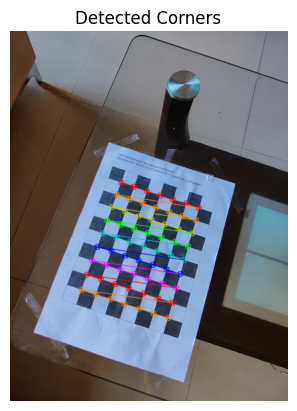

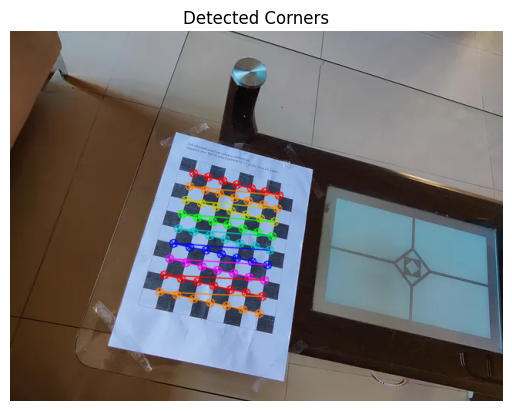

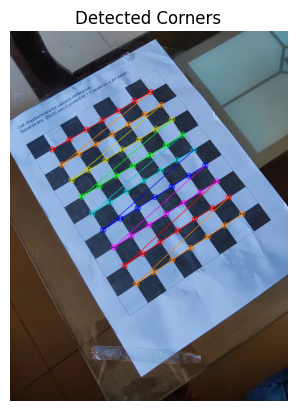


Intrinsic Parameters

Camera Matrix:
[[565.44109346   0.         325.96103312]
 [  0.         520.78425203 107.84755119]
 [  0.           0.           1.        ]]

Distortion Coefficients:
[[ 0.0958962  -0.09902571 -0.02850685  0.01584435  0.08168849]]

Extrinsic Parameters

Image 1
Rotation Vector:
[[-0.21968104]
 [ 0.01007638]
 [ 0.30749188]]
Rotation Matrix:
[[ 0.95323455 -0.30131364 -0.02353665]
 [ 0.29912629  0.92944085  0.21601662]
 [-0.04321283 -0.21295493  0.97610596]]
Translation Vector:
[[-0.08876736]
 [ 0.15324558]
 [ 0.42797738]]

Image 2
Rotation Vector:
[[-0.48382834]
 [-0.26276455]
 [ 0.25398726]]
Rotation Matrix:
[[ 0.93524358 -0.17706532 -0.30654088]
 [ 0.3003507   0.85521872  0.42236288]
 [ 0.18737368 -0.48708194  0.85301951]]
Translation Vector:
[[-0.08845153]
 [ 0.08385346]
 [ 0.56292719]]

Image 3
Rotation Vector:
[[-0.23081062]
 [-0.07308922]
 [-0.58898408]]
Rotation Matrix:
[[ 0.82974971  0.55812987 -0.00254286]
 [-0.54182254  0.80658296  0.23633083]
 [ 0.13395

In [7]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# Chessboard configuration
num_squares_x = 8
num_squares_y = 10

corners_x = num_squares_x - 1
corners_y = num_squares_y - 1

checker_size = 0.020

# Image folder path
path = r"C:\Users\lenovo\Desktop\IPCV\images"

# Termination criteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Prepare object points
objp = np.zeros((corners_x * corners_y, 3), np.float32)
objp[:, :2] = np.mgrid[0:corners_x, 0:corners_y].T.reshape(-1, 2)
objp = objp * checker_size

objpoints = []
imgpoints = []

# Load images (.jpg, .png, .webp supported)
images = glob.glob(os.path.join(path, '*.jpg')) + \
         glob.glob(os.path.join(path, '*.png')) + \
         glob.glob(os.path.join(path, '*.webp'))

print("Images found:", images)

image_size = None

for fname in images:

    img = cv2.imread(fname)

    if img is None:
        print("Cannot read:", fname)
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    image_size = gray.shape[::-1]

    ret, corners = cv2.findChessboardCorners(gray, (corners_x, corners_y), None)

    if ret:

        objpoints.append(objp)

        corners2 = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)

        imgpoints.append(corners2)

        cv2.drawChessboardCorners(img, (corners_x, corners_y), corners2, ret)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img_rgb)
        plt.title("Detected Corners")
        plt.axis("off")
        plt.show()

# Perform camera calibration
ret, camera_matrix, dist_coeff, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, image_size, None, None
)

print("\nIntrinsic Parameters")

print("\nCamera Matrix:")
print(camera_matrix)

print("\nDistortion Coefficients:")
print(dist_coeff)

print("\nExtrinsic Parameters")

for i, (rvec, tvec) in enumerate(zip(rvecs, tvecs)):

    R, _ = cv2.Rodrigues(rvec)

    print("\nImage", i+1)

    print("Rotation Vector:")
    print(rvec)

    print("Rotation Matrix:")
    print(R)

    print("Translation Vector:")
    print(tvec)